# Sorgoleone key genes exploration

In [4]:
import pandas as pd
import matplotlib_venn

In [5]:
df = pd.read_csv("/Users/daffa/workspace/infobio/thesis/analysis/data/tsv/merged.annotated.tsv", sep="\t")

In [6]:
df

,chrom,pos,ref,alt,qual,GT_SBC4,GT_SBC10,GT_SBC11,GT_SBC23,allele,...,feature_id,biotype,rank,hgvs_c,hgvs_p,cdna_pos,cds_pos,aa_pos,distance,extra
0,1,275,C,T,38.180000,"[-1, -1, False]","[1, 1, False]","[1, 1, False]","[1, 1, False]",T,...,EER90453,protein_coding,NaN,c.-1676C>T,NaN,NaN,NaN,NaN,1676.0,NaN
1,1,275,C,T,38.180000,"[-1, -1, False]","[1, 1, False]","[1, 1, False]","[1, 1, False]",T,...,CHR_START-SORBI_3001G000100,NaN,NaN,n.275C>T,NaN,NaN,NaN,NaN,NaN,NaN
2,1,438,T,C,110.000000,"[1, 1, False]","[1, 1, False]","[1, 1, False]","[1, 1, False]",C,...,EER90453,protein_coding,NaN,c.-1513T>C,NaN,NaN,NaN,NaN,1513.0,NaN
3,1,438,T,C,110.000000,"[1, 1, False]","[1, 1, False]","[1, 1, False]","[1, 1, False]",C,...,CHR_START-SORBI_3001G000100,NaN,NaN,n.438T>C,NaN,NaN,NaN,NaN,NaN,NaN
4,1,465,GAAGCT,G,48.810001,"[1, 1, False]","[1, 1, False]","[1, 1, False]","[1, 1, False]",G,...,EER90453,protein_coding,NaN,c.-1485_-1481delAAGCT,NaN,NaN,NaN,NaN,1485.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10496024,10,61233619,T,G,27.490000,"[-1, -1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",G,...,SORBI_3010G280100-CHR_END,NaN,NaN,n.61233619T>G,NaN,NaN,NaN,NaN,NaN,NaN
10496025,10,61233644,A,AG,35.650002,"[-1, -1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",AG,...,SORBI_3010G280100-CHR_END,NaN,NaN,n.61233644_61233645insG,NaN,NaN,NaN,NaN,NaN,NaN
10496026,10,61233646,C,G,33.669998,"[-1, -1, False]","[1, 1, False]","[1, 1, False]","[-1, -1, False]",G,...,SORBI_3010G280100-CHR_END,NaN,NaN,n.61233646C>G,NaN,NaN,NaN,NaN,NaN,NaN
10496027,10,61233647,T,G,33.240002,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",G,...,SORBI_3010G280100-CHR_END,NaN,NaN,n.61233647T>G,NaN,NaN,NaN,NaN,NaN,NaN


### Confirmation about SnpEFF annotation of variant's impact

In [7]:
df["biotype"].unique()

array(['protein_coding', nan, 'pseudogene', 'snRNA', 'snoRNA', 'rRNA',
       'sense_intronic', 'lincRNA'], dtype=object)

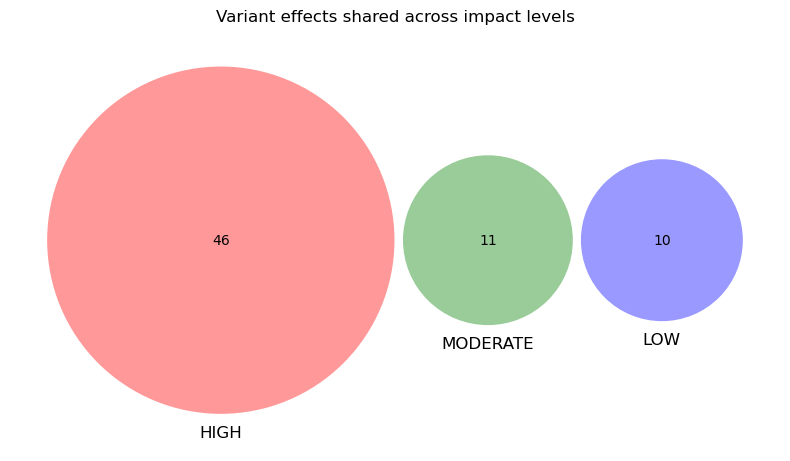

In [8]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Build effect sets per impact level
high     = set(df[df["impact"] == "HIGH"]["effect"].unique())
moderate = set(df[df["impact"] == "MODERATE"]["effect"].unique())
low      = set(df[df["impact"] == "LOW"]["effect"].unique())

fig, ax = plt.subplots(figsize=(8, 6))
v = venn3([high, moderate, low], set_labels=("HIGH", "MODERATE", "LOW"), ax=ax)
ax.set_title("Variant effects shared across impact levels")
plt.tight_layout()
plt.show()

## Filtering to only key sorgholeone genes

In [9]:
SORGOLEONE_GENES = [
    "SORBI_3004G260600", # 8066368
    "SORBI_3005G002700", # 8079957
    "SORBI_3006G007900", # 8080259
    "SORBI_3004G139300", # 8081692
    ]

In [10]:
sorg_df = df[df["gene_id"].isin(SORGOLEONE_GENES)].copy()
print(f"{len(sorg_df)} annotation rows across {sorg_df[['chrom','pos','ref','alt']].drop_duplicates().shape[0]} unique variant sites")
sorg_df # dataframe for variant sites in 4 key genes only

824 annotation rows across 816 unique variant sites


,chrom,pos,ref,alt,qual,GT_SBC4,GT_SBC10,GT_SBC11,GT_SBC23,allele,...,feature_id,biotype,rank,hgvs_c,hgvs_p,cdna_pos,cds_pos,aa_pos,distance,extra
4411511,4,39971388,A,G,64.919998,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",G,...,EES05008,protein_coding,NaN,c.-4963A>G,NaN,NaN,NaN,NaN,4776.0,NaN
4411513,4,39971539,C,T,36.919998,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.-4812C>T,NaN,NaN,NaN,NaN,4625.0,NaN
4411515,4,39971540,G,A,28.830000,"[-1, -1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",A,...,EES05008,protein_coding,NaN,c.-4811G>A,NaN,NaN,NaN,NaN,4624.0,NaN
4411517,4,39971610,C,T,31.309999,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.-4741C>T,NaN,NaN,NaN,NaN,4554.0,NaN
4411519,4,39971619,C,T,29.760000,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.-4732C>T,NaN,NaN,NaN,NaN,4545.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5878895,6,1189911,G,A,31.610001,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",A,...,EES11753,protein_coding,NaN,c.-4224C>T,NaN,NaN,NaN,NaN,4165.0,NaN
5878897,6,1190434,G,T,29.590000,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES11753,protein_coding,NaN,c.-4747C>A,NaN,NaN,NaN,NaN,4688.0,NaN
5878899,6,1190466,A,G,30.730000,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",G,...,EES11753,protein_coding,NaN,c.-4779T>C,NaN,NaN,NaN,NaN,4720.0,NaN
5878901,6,1190674,G,C,28.270000,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",C,...,EES11753,protein_coding,NaN,c.-4987C>G,NaN,NaN,NaN,NaN,4928.0,NaN


In [11]:
sorg_df["effect"].unique()

array(['upstream_gene_variant', '5_prime_UTR_variant',
       'synonymous_variant', 'missense_variant', '3_prime_UTR_variant',
       'downstream_gene_variant', 'frameshift_variant',
       'splice_region_variant&intron_variant', 'intron_variant'],
      dtype=object)

In [12]:
sorg_df.groupby("gene_id")[["chrom","pos","ref","alt"]].apply(
    lambda g: g.drop_duplicates().shape[0]
).rename("variant_sites").reset_index()

,gene_id,variant_sites
0,SORBI_3004G139300,100
1,SORBI_3004G260600,272
2,SORBI_3005G002700,87
3,SORBI_3006G007900,357


In [13]:
sorg_df.drop_duplicates(subset=["gene_id", "chrom", "pos", "ref", "alt", "impact"]).groupby(["gene_id", "impact"]).size().rename("variant_sites").reset_index()

,gene_id,impact,variant_sites
0,SORBI_3004G139300,LOW,3
1,SORBI_3004G139300,MODERATE,4
2,SORBI_3004G139300,MODIFIER,93
3,SORBI_3004G260600,HIGH,2
4,SORBI_3004G260600,LOW,4
5,SORBI_3004G260600,MODERATE,3
6,SORBI_3004G260600,MODIFIER,263
7,SORBI_3005G002700,LOW,3
8,SORBI_3005G002700,MODIFIER,84
9,SORBI_3006G007900,LOW,13


## Expanding to other genes highly co-expressed

In [14]:
SORG_GENES = {
    "8066368": "SORBI_3004G260600", # SbDES2
    "8079957": "SORBI_3005G002700", # SbDES3
    "8080259": "SORBI_3006G007900", # SbOMT3
    "8081692": "SORBI_3004G139300", # SbCYP71AM1
}

SbDES2_GENES = {
    "8066368": "SORBI_3004G260600", # SbDES2
    "110435045": "SORBI_3004G260800",
}

SbDES3_GENES = {
    "8079957": "SORBI_3005G002700", # SbDES3
    "8079958": "SORBI_3005G002800",
    "8072903": "SORBI_3008G002800",
    "8055482": "SORBI_3008G003200",
}

SbOMT3_GENES = {
    "8080259": "SORBI_3006G007900", # SbOMT3
    "8085153": "SORBI_3007G074800",
    "8076922": "SORBI_3005G086600",
    "110436225": "SORBI_3006G008000",
}

SbCYP71AM1_GENES = {
    "8081692": "SORBI_3004G139300",
}

In [15]:
def coex_cluster(gene_name_dict):
    return df[df["gene_id"].isin(list(gene_name_dict.values()))].copy()

df_SbDES2 = coex_cluster(SbDES2_GENES) #, "SbDES2")
df_SbDES3 = coex_cluster(SbDES3_GENES) #, "SbDES3")
df_SbOMT3 = coex_cluster(SbOMT3_GENES) #, "SbOMT3")
df_SbCYP71AM1 = coex_cluster(SbCYP71AM1_GENES) #, "SbCYP71AM1")

# def coex_cluster_to_csv(gene_name_dict, name):
#     df_gene_name = coex_cluster(gene_name_dict)
#     df_gene_name.to_csv(f"{name}.tsv", sep="\t")
#     return df_gene_name

# df_SbDES2 = coex_cluster_to_csv(SbDES2_GENES, "SbDES2")
# df_SbDES3 = coex_cluster_to_csv(SbDES3_GENES, "SbDES3")
# df_SbOMT3 = coex_cluster_to_csv(SbOMT3_GENES, "SbOMT3")
# df_SbCYP71AM1 = coex_cluster_to_csv(SbCYP71AM1_GENES, "SbCYP71AM1")

In [16]:
df_SbDES2

,chrom,pos,ref,alt,qual,GT_SBC4,GT_SBC10,GT_SBC11,GT_SBC23,allele,...,feature_id,biotype,rank,hgvs_c,hgvs_p,cdna_pos,cds_pos,aa_pos,distance,extra
4816835,4,60578500,C,T,57.250000,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",T,...,EES05625,protein_coding,NaN,c.-5094C>T,NaN,NaN,NaN,NaN,4996.0,NaN
4816838,4,60578520,T,C,20.010000,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",C,...,EES05625,protein_coding,NaN,c.-5074T>C,NaN,NaN,NaN,NaN,4976.0,NaN
4816841,4,60578523,TCCTTCTTCACGC,T,30.270000,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",T,...,EES05625,protein_coding,NaN,c.-5070_-5059delCCTTCTTCACGC,NaN,NaN,NaN,NaN,4972.0,NaN
4816844,4,60578534,G,C,76.220001,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",C,...,EES05625,protein_coding,NaN,c.-5060G>C,NaN,NaN,NaN,NaN,4962.0,NaN
4816847,4,60578550,A,G,28.620001,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",G,...,EES05625,protein_coding,NaN,c.-5044A>G,NaN,NaN,NaN,NaN,4946.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4817986,4,60630389,T,C,24.510000,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",C,...,KXG30881,protein_coding,NaN,c.*5162T>C,NaN,NaN,NaN,NaN,4625.0,NaN
4817988,4,60630395,T,C,29.299999,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",C,...,KXG30881,protein_coding,NaN,c.*5168T>C,NaN,NaN,NaN,NaN,4631.0,NaN
4817990,4,60630407,T,C,38.939999,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 1, False]",C,...,KXG30881,protein_coding,NaN,c.*5180T>C,NaN,NaN,NaN,NaN,4643.0,NaN
4817992,4,60630419,T,C,30.969999,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[0, 1, False]",C,...,KXG30881,protein_coding,NaN,c.*5192T>C,NaN,NaN,NaN,NaN,4655.0,NaN


In [17]:
df_SbDES3

,chrom,pos,ref,alt,qual,GT_SBC4,GT_SBC10,GT_SBC11,GT_SBC23,allele,...,feature_id,biotype,rank,hgvs_c,hgvs_p,cdna_pos,cds_pos,aa_pos,distance,extra
4976709,5,202176,TTA,T,52.450001,"[1, 1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES09078,protein_coding,NaN,c.*5173_*5174delTA,NaN,NaN,NaN,NaN,4891.0,NaN
4976713,5,202189,G,T,43.029999,"[1, 1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES09078,protein_coding,NaN,c.*5162C>A,NaN,NaN,NaN,NaN,4879.0,NaN
4976717,5,202360,C,T,58.590000,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",T,...,EES09078,protein_coding,NaN,c.*4991G>A,NaN,NaN,NaN,NaN,4708.0,NaN
4976720,5,202778,AGCCCGGCCGCT,A,44.169998,"[1, 1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",A,...,EES09078,protein_coding,NaN,c.*4562_*4572delAGCGGCCGGGC,NaN,NaN,NaN,NaN,4289.0,NaN
4976723,5,202808,G,T,72.250000,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES09078,protein_coding,NaN,c.*4543C>A,NaN,NaN,NaN,NaN,4260.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7727284,8,289042,T,C,20.990000,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 0, True]",C,...,EES16485,protein_coding,NaN,c.-4118A>G,NaN,NaN,NaN,NaN,4118.0,NaN
7727286,8,289042,T,C,20.990000,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 0, True]",C,...,OQU78574,protein_coding,NaN,c.-4118A>G,NaN,NaN,NaN,NaN,3835.0,NaN
7727293,8,289169,T,C,20.870001,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 0, True]",C,...,EES16485,protein_coding,NaN,c.-4245A>G,NaN,NaN,NaN,NaN,4245.0,NaN
7727295,8,289169,T,C,20.870001,"[-1, -1, False]","[-1, -1, False]","[-1, -1, False]","[1, 0, True]",C,...,OQU78574,protein_coding,NaN,c.-4245A>G,NaN,NaN,NaN,NaN,3962.0,NaN


In [18]:
df_SbOMT3

,chrom,pos,ref,alt,qual,GT_SBC4,GT_SBC10,GT_SBC11,GT_SBC23,allele,...,feature_id,biotype,rank,hgvs_c,hgvs_p,cdna_pos,cds_pos,aa_pos,distance,extra
5232273,5,12026111,A,G,32.110001,"[-1, -1, False]","[1, 1, False]","[1, 1, False]","[-1, -1, False]",G,...,KXG28109,protein_coding,NaN,c.*5093T>C,NaN,NaN,NaN,NaN,4884.0,NaN
5232275,5,12026311,T,G,54.000000,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",G,...,KXG28109,protein_coding,NaN,c.*4893A>C,NaN,NaN,NaN,NaN,4684.0,NaN
5232277,5,12026338,TTA,T,54.080002,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",T,...,KXG28109,protein_coding,NaN,c.*4864_*4865delTA,NaN,NaN,NaN,NaN,4656.0,NaN
5232279,5,12026772,A,G,50.419998,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",G,...,KXG28109,protein_coding,NaN,c.*4432T>C,NaN,NaN,NaN,NaN,4223.0,NaN
5232281,5,12026781,G,A,40.860001,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",A,...,KXG28109,protein_coding,NaN,c.*4423C>T,NaN,NaN,NaN,NaN,4214.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7193483,7,8585185,T,TA,72.250000,"[1, 1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",TA,...,EES13512,protein_coding,NaN,c.*402_*403insA,NaN,NaN,NaN,NaN,155.0,NaN
7193485,7,8585214,T,G,45.389999,"[1, 1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",G,...,EES13512,protein_coding,NaN,c.*431T>G,NaN,NaN,NaN,NaN,183.0,NaN
7193487,7,8585218,T,G,33.240002,"[1, 1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",G,...,EES13512,protein_coding,NaN,c.*435T>G,NaN,NaN,NaN,NaN,187.0,NaN
7193489,7,8585219,A,T,38.799999,"[1, 1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",T,...,EES13512,protein_coding,NaN,c.*436A>T,NaN,NaN,NaN,NaN,188.0,NaN


In [19]:
df_SbCYP71AM1

,chrom,pos,ref,alt,qual,GT_SBC4,GT_SBC10,GT_SBC11,GT_SBC23,allele,...,feature_id,biotype,rank,hgvs_c,hgvs_p,cdna_pos,cds_pos,aa_pos,distance,extra
4411511,4,39971388,A,G,64.919998,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",G,...,EES05008,protein_coding,NaN,c.-4963A>G,NaN,NaN,NaN,NaN,4776.0,NaN
4411513,4,39971539,C,T,36.919998,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.-4812C>T,NaN,NaN,NaN,NaN,4625.0,NaN
4411515,4,39971540,G,A,28.830000,"[-1, -1, False]","[1, 1, False]","[-1, -1, False]","[-1, -1, False]",A,...,EES05008,protein_coding,NaN,c.-4811G>A,NaN,NaN,NaN,NaN,4624.0,NaN
4411517,4,39971610,C,T,31.309999,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.-4741C>T,NaN,NaN,NaN,NaN,4554.0,NaN
4411519,4,39971619,C,T,29.760000,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.-4732C>T,NaN,NaN,NaN,NaN,4545.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4411710,4,39982391,A,G,32.500000,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",G,...,EES05008,protein_coding,NaN,c.*4363A>G,NaN,NaN,NaN,NaN,4315.0,NaN
4411714,4,39982395,T,C,45.700001,"[1, 1, False]","[-1, -1, False]","[-1, -1, False]","[-1, -1, False]",C,...,EES05008,protein_coding,NaN,c.*4367T>C,NaN,NaN,NaN,NaN,4319.0,NaN
4411718,4,39982492,A,T,34.540001,"[-1, -1, False]","[-1, -1, False]","[1, 1, False]","[-1, -1, False]",T,...,EES05008,protein_coding,NaN,c.*4464A>T,NaN,NaN,NaN,NaN,4416.0,NaN
4411723,4,39982715,C,A,36.560001,"[1, 1, False]","[-1, -1, False]","[1, 1, False]","[1, 1, False]",A,...,EES05008,protein_coding,NaN,c.*4687C>A,NaN,NaN,NaN,NaN,4639.0,NaN
